# Predicción de Attrition – IBM HR Analytics Employee Attrition & Performance

**Data Mining Empresarial – Unidad 3: Aplicaciones de Data Mining en RRHH**

**Objetivo:** construir un modelo que prediga si un empleado abandonará la compañía (*attrition* voluntario) a partir de sus datos estáticos y dinámicos, y detectar los factores que más influyen, para que RRHH pueda actuar antes de perder al empleado.

**Metodología.** Se siguen las cinco etapas propuestas por Setiawan et al. (2020), *HR analytics: Employee attrition analysis using logistic regression*:

1. Recolección de datos y entendimiento del negocio
2. Pre-procesado de datos (limpieza, selección de atributos, transformación: normalización, discretización y derivación — según el material de la unidad)
3. Análisis exploratorio de datos (EDA)
4. Selección y entrenamiento de modelos
5. Prueba y evaluación de los modelos

A diferencia del paper (que usa sólo regresión logística), acá se comparan los algoritmos de clasificación vistos: **Regresión Logística, Árbol de Decisión (tipo C4.5), Naive Bayes, K-Vecinos más cercanos (KNN), Random Forest, SVM y Red Neuronal (MLP)**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)

SEED = 42
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Recolección de datos y entendimiento del negocio

El dataset es ficticio, creado por científicos de datos de IBM. Tiene **1.470 empleados** y **35 variables**: datos demográficos (edad, género, estado civil), laborales (departamento, rol, nivel, salario, antigüedad, horas extra, viajes) y de encuestas (satisfacción con el ambiente, el trabajo y las relaciones, involucramiento, balance vida-trabajo, desempeño).

La variable objetivo es **`Attrition`** (Yes/No). Como se vio en clase, el attrition voluntario es una de las principales preocupaciones de las compañías por el costo de encontrar y capacitar reemplazos; por eso interesa especialmente **detectar a los que se van** (sensibilidad), más que la exactitud global.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Filas x columnas:", df.shape)
df.head()

Filas x columnas: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Attrition
No     1233
Yes     237
Name: count, dtype: int64 

Tasa de attrition: 16.12%


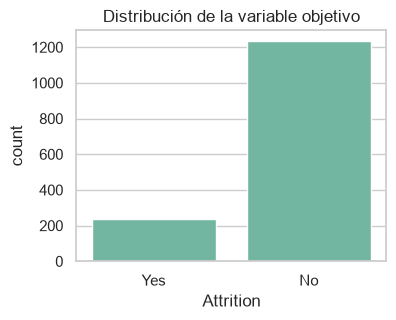

In [4]:
tasa = df["Attrition"].value_counts()
print(tasa, "\n")
print(f"Tasa de attrition: {tasa['Yes'] / len(df):.2%}")

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(data=df, x="Attrition", ax=ax)
ax.set_title("Distribución de la variable objetivo")
plt.show()

La tasa de attrition es **16,1 %** (muy similar al 15,7 % del paper). Las clases están **desbalanceadas** (≈ 5 empleados que se quedan por cada uno que se va): un modelo que diga siempre "No" tendría 84 % de *accuracy* sin servir para nada. Por eso se evaluará con **sensibilidad, especificidad, F1 y AUC**, y se compensará el desbalance con pesos de clase.

## 2. Pre-procesado de datos

### 2.1 Limpieza: valores perdidos, duplicados y outliers

In [5]:
print("Valores perdidos totales:", df.isna().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

Valores perdidos totales: 0
Filas duplicadas: 0


In [6]:
# Detección de outliers con el criterio del rango intercuartílico (IQR)
num_cols = df.select_dtypes("number").columns
q1, q3 = df[num_cols].quantile(0.25), df[num_cols].quantile(0.75)
iqr = q3 - q1
outliers = ((df[num_cols] < q1 - 1.5 * iqr) | (df[num_cols] > q3 + 1.5 * iqr)).sum()
outliers[outliers > 0].sort_values(ascending=False).to_frame("n_outliers")

,n_outliers
TrainingTimesLastYear,238
PerformanceRating,226
MonthlyIncome,114
YearsSinceLastPromotion,107
YearsAtCompany,104
StockOptionLevel,85
TotalWorkingYears,63
NumCompaniesWorked,52
YearsInCurrentRole,21
YearsWithCurrManager,14


No hay valores perdidos ni duplicados. Los *outliers* detectados (ingreso mensual, años en la compañía, etc.) son **valores plausibles** (gerentes con salarios altos o empleados con mucha antigüedad), no errores de carga, por lo que **se conservan**: eliminarlos haría perder justamente perfiles de interés y con sólo 1.470 registros cada caso cuenta. La normalización min-max y los modelos basados en árboles atenúan su efecto.

### 2.2 Selección de atributos: variables irrelevantes
Como indica el material, se eliminan atributos irrelevantes: identificadores y variables con un único valor (no aportan información).

In [7]:
unicos = df.nunique()
print("Variables con un solo valor:", list(unicos[unicos == 1].index))

df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])
print("Nuevas dimensiones:", df.shape)

Variables con un solo valor: ['EmployeeCount', 'Over18', 'StandardHours']
Nuevas dimensiones: (1470, 31)


### 2.3 Transformación: codificación del objetivo y derivación de atributos

- `Attrition` se convierte a 0/1 (como en el paper).
- **Derivación** (crear nuevos atributos a partir de los existentes):
  - `IngresoPorNivel` = ingreso mensual / nivel del puesto → ¿el empleado cobra poco para su nivel?
  - `AniosPromPorEmpresa` = años totales trabajados / (empresas + 1) → estabilidad laboral histórica.
  - `ProporcionAniosEnEmpresa` = años en la compañía / (años totales + 1).
  - `AniosSinPromocionRel` = años desde la última promoción / (años en la compañía + 1).
  - `SatisfaccionTotal` = promedio de las 4 encuestas de satisfacción/involucramiento.

In [8]:
df["Attrition"] = (df["Attrition"] == "Yes").astype(int)

df["IngresoPorNivel"] = df["MonthlyIncome"] / df["JobLevel"]
df["AniosPromPorEmpresa"] = df["TotalWorkingYears"] / (df["NumCompaniesWorked"] + 1)
df["ProporcionAniosEnEmpresa"] = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)
df["AniosSinPromocionRel"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["SatisfaccionTotal"] = df[["EnvironmentSatisfaction", "JobSatisfaction",
                              "RelationshipSatisfaction", "JobInvolvement"]].mean(axis=1)

df[["IngresoPorNivel", "AniosPromPorEmpresa", "ProporcionAniosEnEmpresa",
    "AniosSinPromocionRel", "SatisfaccionTotal"]].describe()

,IngresoPorNivel,AniosPromPorEmpresa,ProporcionAniosEnEmpresa,AniosSinPromocionRel,SatisfaccionTotal
count,1470.000,1470.000,1470.000,1470.000,1470.000
mean,2973.801,4.193,0.582,0.236,2.723
std,770.641,4.036,0.284,0.269,0.504
min,1009.000,0.000,0.000,0.000,1.250
25%,2394.125,1.600,0.368,0.000,2.500
50%,2856.500,3.000,0.636,0.143,2.750
75%,3478.833,5.000,0.833,0.429,3.000
max,4999.000,38.000,0.976,0.917,4.000


### 2.4 Transformación: discretización (sólo para el análisis exploratorio)
Para facilitar la interpretación se discretizan la edad y el ingreso (particionado manual e igual frecuencia), y se etiquetan las escalas ordinales de las encuestas tal como las define IBM. Estas versiones categóricas se usan en el EDA; los modelos usan los valores numéricos originales.

In [9]:
eda = df.copy()
eda["RangoEdad"] = pd.cut(eda["Age"], bins=[17, 25, 35, 45, 60],
                          labels=["18-25", "26-35", "36-45", "46-60"])
eda["QuintilIngreso"] = pd.qcut(eda["MonthlyIncome"], q=5,
                                labels=["Q1 (bajo)", "Q2", "Q3", "Q4", "Q5 (alto)"])
escala = {1: "1-Bajo", 2: "2-Medio", 3: "3-Alto", 4: "4-Muy alto"}
for c in ["EnvironmentSatisfaction", "JobSatisfaction", "RelationshipSatisfaction", "JobInvolvement"]:
    eda[c] = eda[c].map(escala)
eda["WorkLifeBalance"] = eda["WorkLifeBalance"].map({1: "1-Malo", 2: "2-Bueno", 3: "3-Mejor", 4: "4-Óptimo"})
eda[["Age", "RangoEdad", "MonthlyIncome", "QuintilIngreso"]].head()

,Age,RangoEdad,MonthlyIncome,QuintilIngreso
0,41,36-45,5993,Q4
1,49,46-60,5130,Q3
2,37,36-45,2090,Q1 (bajo)
3,33,26-35,2909,Q2
4,27,26-35,3468,Q2


## 3. Análisis exploratorio de datos (EDA)

### 3.1 Variables categóricas: tasa de attrition por categoría
(Equivalente a la Figura 8 del paper.) La línea punteada marca la tasa general (16,1 %).

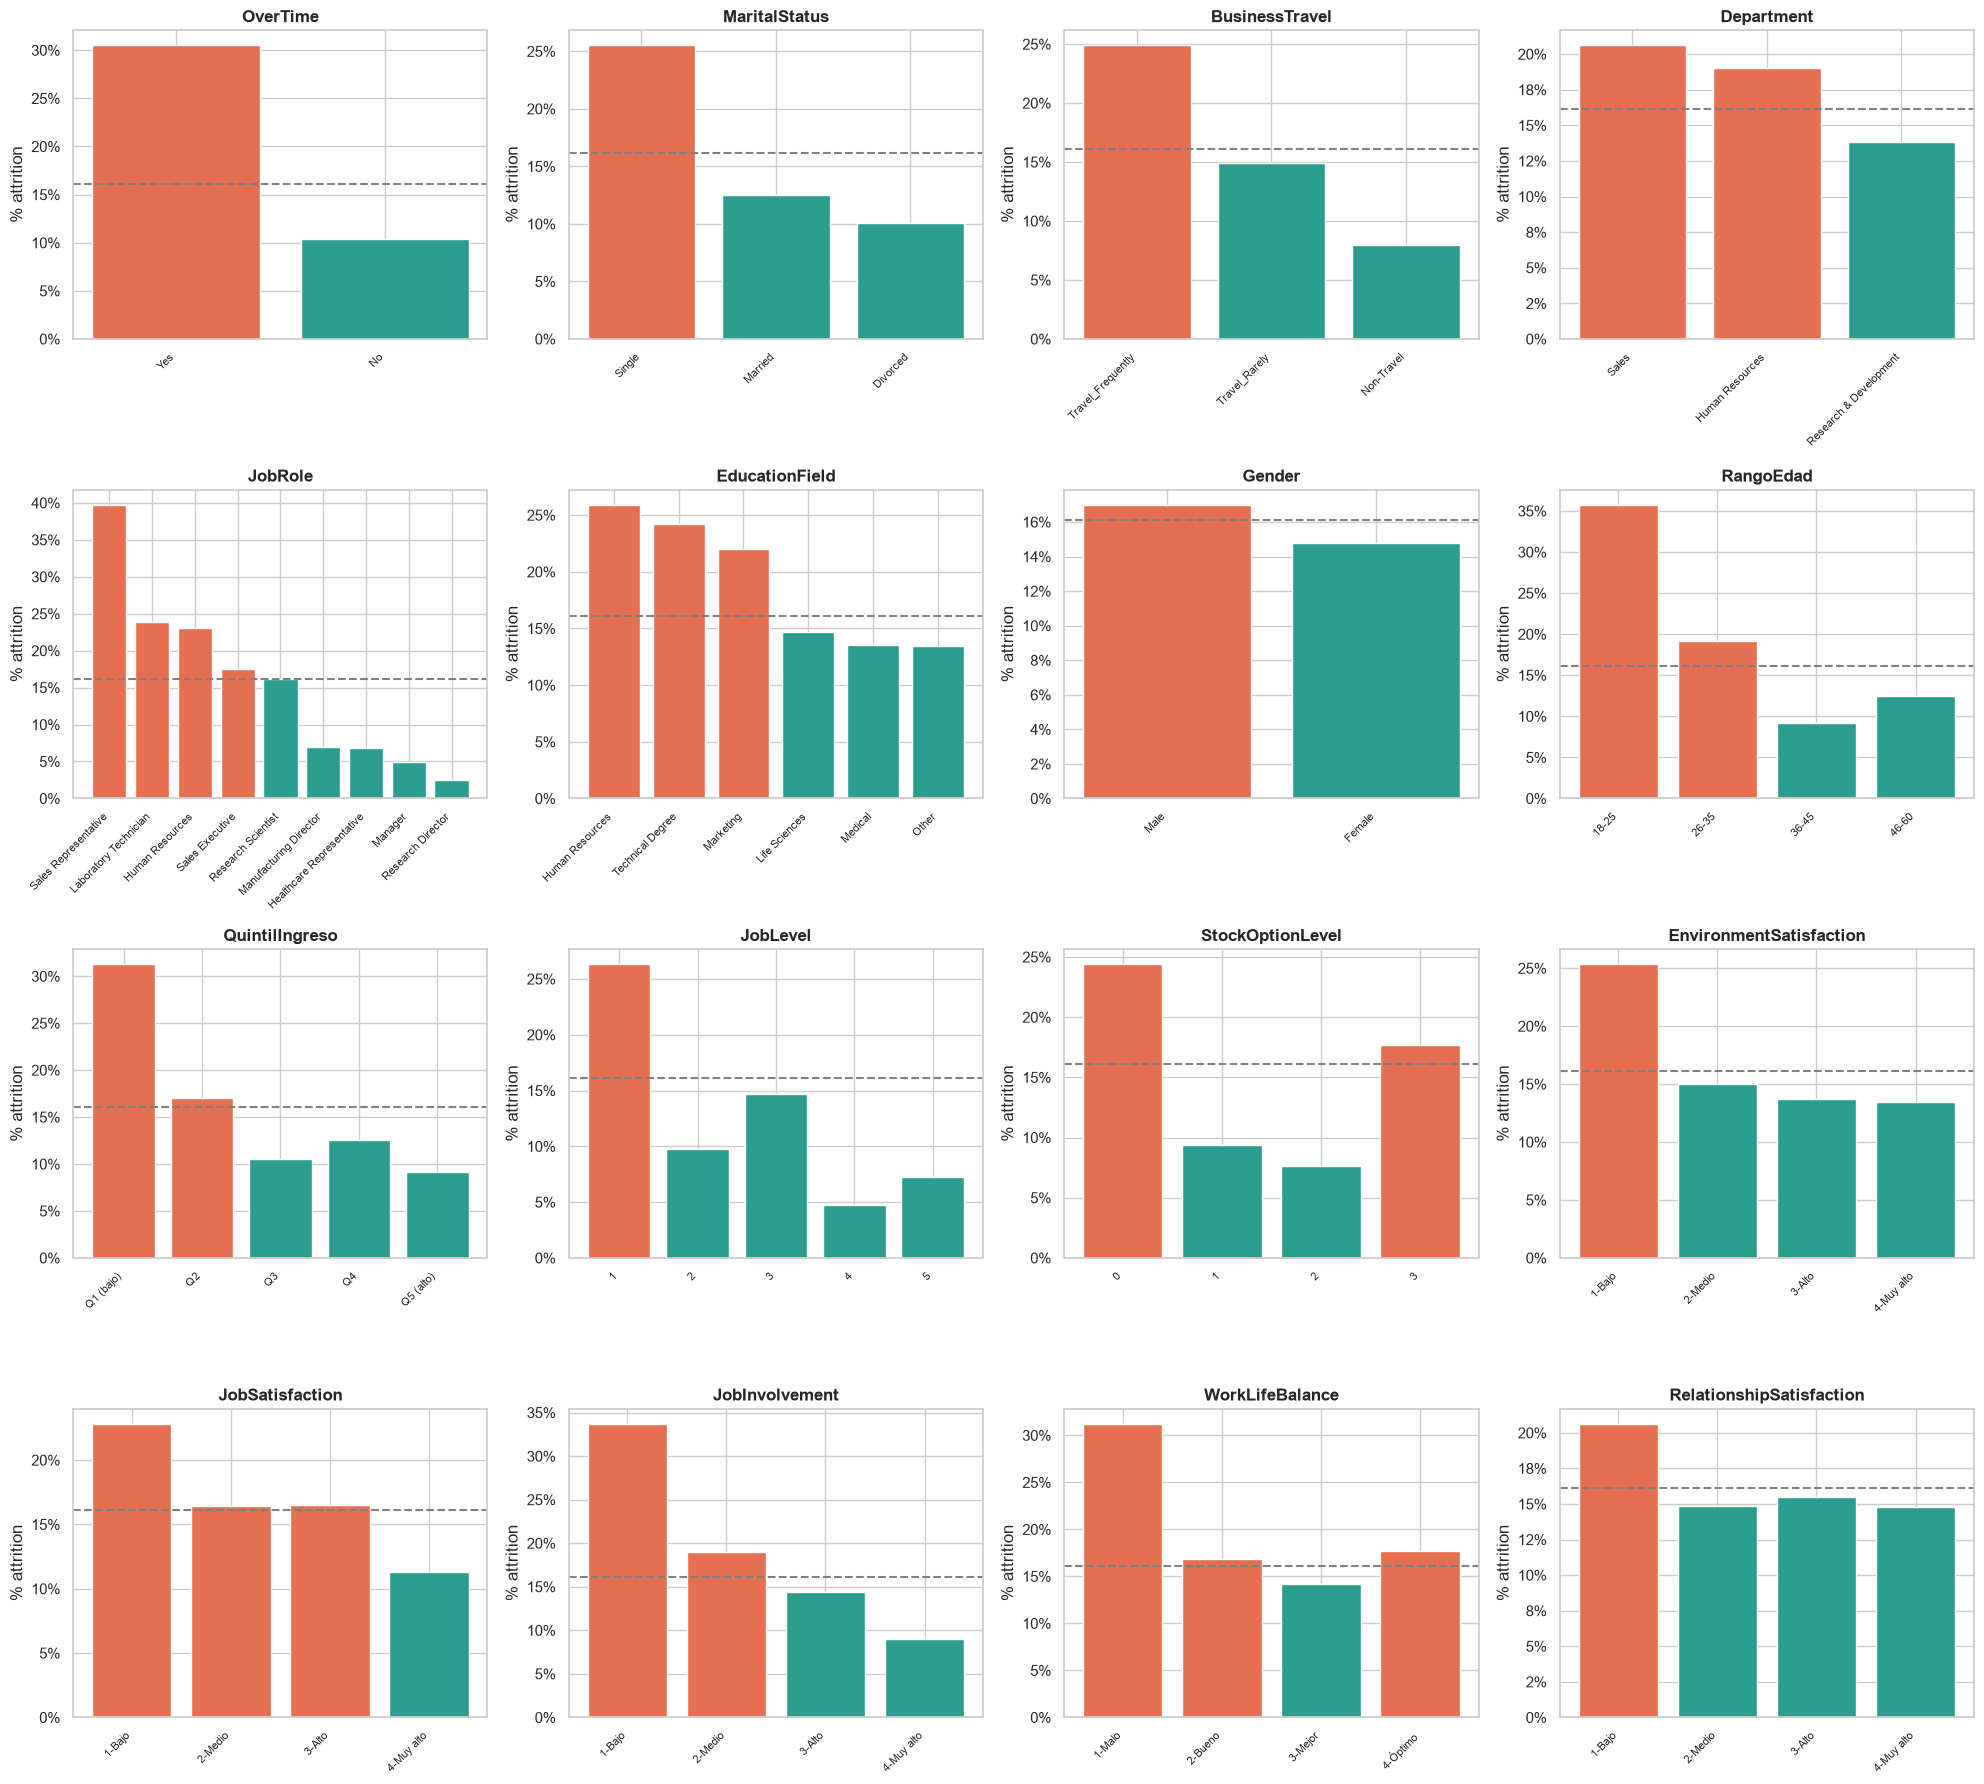

In [10]:
cat_eda = ["OverTime", "MaritalStatus", "BusinessTravel", "Department", "JobRole", "EducationField",
           "Gender", "RangoEdad", "QuintilIngreso", "JobLevel", "StockOptionLevel",
           "EnvironmentSatisfaction", "JobSatisfaction", "JobInvolvement", "WorkLifeBalance",
           "RelationshipSatisfaction"]
nominales_eda = ["OverTime", "MaritalStatus", "BusinessTravel", "Department", "JobRole", "EducationField", "Gender"]
base = df["Attrition"].mean()

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
for ax, c in zip(axes.ravel(), cat_eda):
    t = eda.groupby(c, observed=True)["Attrition"].mean()
    if c in nominales_eda:                      # nominales: ordenadas por tasa; ordinales: orden natural
        t = t.sort_values(ascending=False)
    ax.bar(t.index.astype(str), t.values, color=["#e76f51" if v > base else "#2a9d8f" for v in t.values])
    ax.axhline(base, ls="--", c="gray")
    ax.set_title(c, fontweight="bold")
    ax.set_ylabel("% attrition")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
plt.tight_layout()
plt.show()

In [11]:
# Tabla resumen: categorías con mayor tasa de attrition (mínimo 30 empleados)
filas = []
for c in cat_eda:
    g = eda.groupby(c, observed=True)["Attrition"].agg(["mean", "size"])
    for k, r in g.iterrows():
        filas.append((c, k, r["size"], r["mean"]))
res = pd.DataFrame(filas, columns=["Variable", "Categoría", "Empleados", "Tasa attrition"])
res[res["Empleados"] >= 30].sort_values("Tasa attrition", ascending=False).head(12)

,Variable,Categoría,Empleados,Tasa attrition
19,JobRole,Sales Representative,83.000,0.398
28,RangoEdad,18-25,123.000,0.358
54,JobInvolvement,1-Bajo,83.000,0.337
32,QuintilIngreso,Q1 (bajo),294.000,0.313
58,WorkLifeBalance,1-Malo,80.000,0.312
1,OverTime,Yes,416.000,0.305
37,JobLevel,1,543.000,0.263
4,MaritalStatus,Single,470.000,0.255
46,EnvironmentSatisfaction,1-Bajo,284.000,0.254
6,BusinessTravel,Travel_Frequently,277.000,0.249


### 3.2 Variables numéricas: comparación entre quienes se van y quienes se quedan

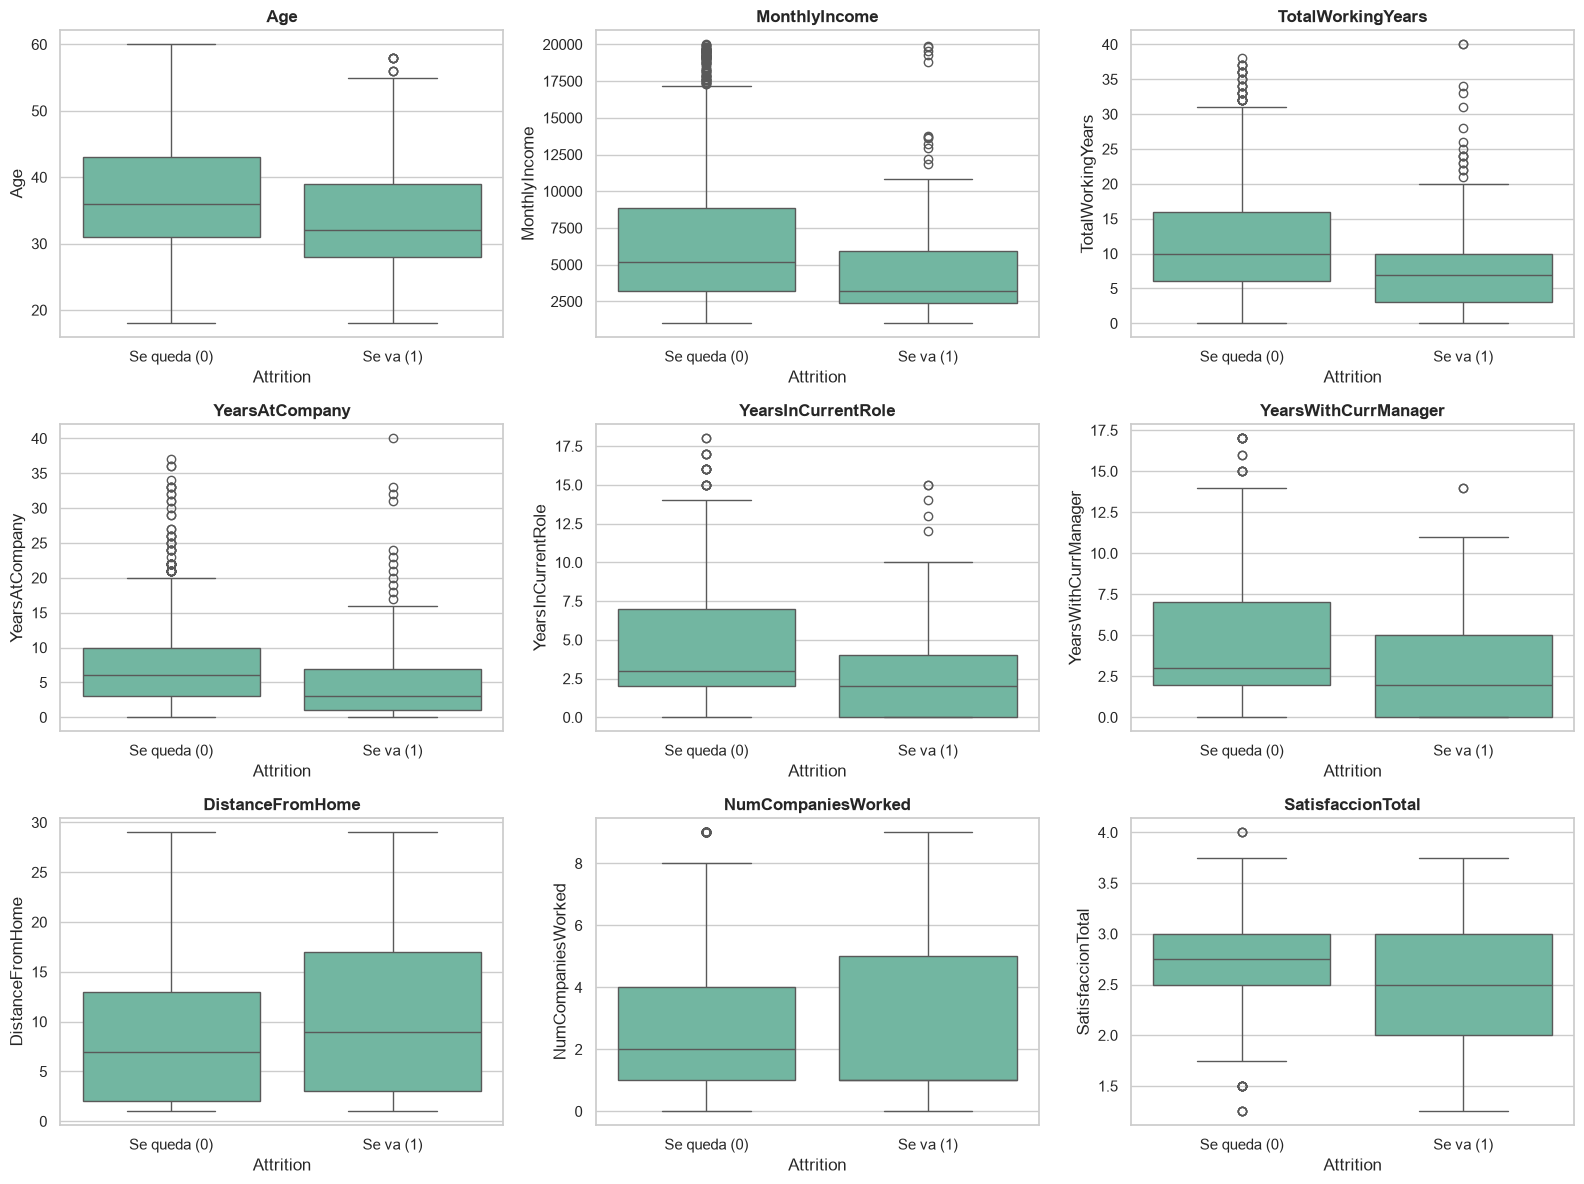

Attrition,Mediana se queda,Mediana se va
Age,36.000,32.000
MonthlyIncome,5204.000,3202.000
TotalWorkingYears,10.000,7.000
YearsAtCompany,6.000,3.000
YearsInCurrentRole,3.000,2.000
YearsWithCurrManager,3.000,2.000
DistanceFromHome,7.000,9.000
NumCompaniesWorked,2.000,1.000
SatisfaccionTotal,2.750,2.500


In [12]:
num_eda = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
           "YearsWithCurrManager", "DistanceFromHome", "NumCompaniesWorked", "SatisfaccionTotal"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), num_eda):
    sns.boxplot(data=df, x="Attrition", y=c, ax=ax)
    ax.set_xticklabels(["Se queda (0)", "Se va (1)"])
    ax.set_title(c, fontweight="bold")
plt.tight_layout()
plt.show()

df.groupby("Attrition")[num_eda].median().T.rename(columns={0: "Mediana se queda", 1: "Mediana se va"})

### 3.3 Correlaciones

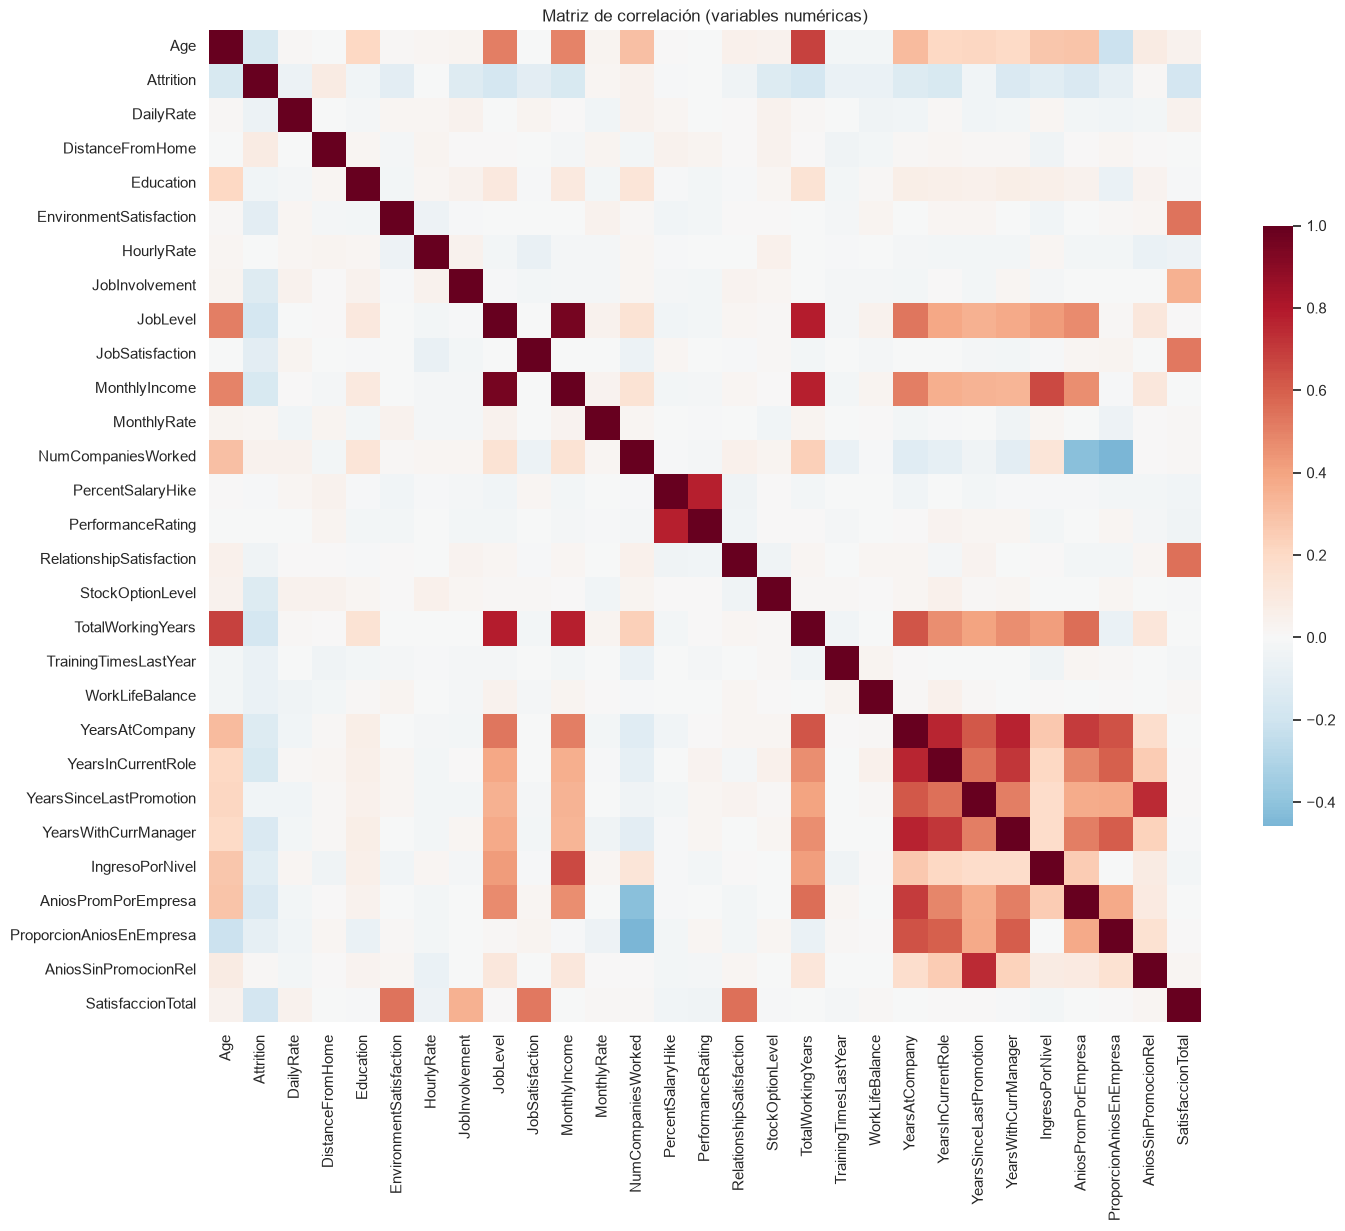

,Correlación con Attrition
SatisfaccionTotal,-0.183
TotalWorkingYears,-0.171
JobLevel,-0.169
YearsInCurrentRole,-0.161
MonthlyIncome,-0.160
Age,-0.159
YearsWithCurrManager,-0.156
AniosPromPorEmpresa,-0.151
StockOptionLevel,-0.137
YearsAtCompany,-0.134


In [13]:
corr = df.select_dtypes("number").corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, square=True, cbar_kws={"shrink": .6})
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

corr["Attrition"].drop("Attrition").sort_values().to_frame("Correlación con Attrition")

**Hallazgos del EDA**

- **Horas extra (`OverTime`)** es el factor más marcado: quienes hacen horas extra se van ~3 veces más (≈ 31 % vs ≈ 10 %). Coincide con el paper, donde *overtime* fue un factor clave.
- **Estado civil soltero**, **viajes frecuentes**, el rol **Sales Representative**, el **nivel de puesto 1**, los **menores de 25 años** y el **quintil de ingreso más bajo** tienen tasas muy superiores al promedio.
- Quienes se van son más **jóvenes**, con **menos años de experiencia, en la empresa y con su jefe actual**, y **menor ingreso** (perfil "junior", también señalado por el paper).
- Las **satisfacciones bajas** (ambiente, trabajo, involucramiento) y el **mal balance vida-trabajo** elevan el attrition.
- Hay fuertes correlaciones entre variables de antigüedad (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) y entre `JobLevel`, `MonthlyIncome` y `TotalWorkingYears` → **multicolinealidad**, que se controla con VIF para la regresión logística.

## 4. Selección y entrenamiento de modelos

### 4.1 Codificación y partición 70 / 30
Las variables nominales se transforman con *one-hot encoding* (una columna 0/1 por categoría, eliminando una de referencia). Se separa **70 % entrenamiento / 30 % prueba** (igual que el paper), de forma **estratificada** para mantener la proporción de attrition en ambos conjuntos.

In [14]:
nominales = ["BusinessTravel", "Department", "EducationField", "Gender", "JobRole", "MaritalStatus", "OverTime"]
X = pd.get_dummies(df.drop(columns="Attrition"), columns=nominales, drop_first=True, dtype=int)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
print("Train:", X_train.shape, f"– attrition {y_train.mean():.1%}")
print("Test: ", X_test.shape, f"– attrition {y_test.mean():.1%}")
print("Total de atributos:", X.shape[1])

Train: (1029, 49) – attrition 16.1%
Test:  (441, 49) – attrition 16.1%
Total de atributos: 49


### 4.2 Normalización min-max
Como indica el material de la unidad, se normaliza al rango [0, 1] con $v' = \frac{v - min_A}{max_A - min_A}$. El escalador se **ajusta sólo con el conjunto de entrenamiento** (dentro de un *pipeline*) para no filtrar información del conjunto de prueba. Es imprescindible para KNN, SVM y redes neuronales, que trabajan con distancias/gradientes.

### 4.3 Regresión logística estadística (enfoque del paper)
Se replica el procedimiento de Setiawan et al.: (a) eliminar multicolinealidad con **VIF**, (b) **eliminación hacia atrás** de variables no significativas (p-valor > 0,05) observando el AIC, hasta quedar con un modelo interpretable.

In [15]:
scaler_sm = MinMaxScaler().fit(X_train)
Xtr_s = pd.DataFrame(scaler_sm.transform(X_train), columns=X.columns, index=X_train.index)

# (a) Eliminación iterativa por VIF > 5
cols = list(Xtr_s.columns)
eliminadas_vif = []
warnings.simplefilter("ignore")
while True:
    Xc = sm.add_constant(Xtr_s[cols])
    vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])], index=cols)
    if vif.max() <= 5:
        break
    peor = vif.idxmax()
    eliminadas_vif.append((peor, round(vif.max(), 1)))
    cols.remove(peor)
print("Eliminadas por VIF > 5:")
for c, v in eliminadas_vif:
    print(f"  {c:35s} VIF={v}")
print("Variables restantes:", len(cols))

Eliminadas por VIF > 5:
  EnvironmentSatisfaction             VIF=1000799917193443.6
  MonthlyIncome                       VIF=103.7
  Department_Sales                    VIF=49.2
  EducationField_Life Sciences        VIF=21.3
  Department_Research & Development   VIF=13.4
  YearsAtCompany                      VIF=12.4
  TotalWorkingYears                   VIF=6.8
  JobLevel                            VIF=5.3
Variables restantes: 41


El primer VIF es enorme (≈ 10¹⁵) porque hay **colinealidad perfecta**: `SatisfaccionTotal` es el promedio exacto de cuatro encuestas, así que una de ellas es combinación lineal de las demás. Luego se eliminan las redundancias detectadas en el EDA: `MonthlyIncome` (explicada por `JobLevel` e `IngresoPorNivel`), las dummies de departamento (redundantes con `JobRole`) y las variables de antigüedad solapadas.

In [16]:
# (b) Eliminación hacia atrás por p-valor (historial de modelos como en la Figura 9 del paper)
historial = []
cols_bw = cols.copy()
while True:
    m = sm.Logit(y_train, sm.add_constant(Xtr_s[cols_bw])).fit(disp=0)
    p = m.pvalues.drop("const")
    historial.append({"Modelo": len(historial) + 1, "N variables": len(cols_bw), "AIC": m.aic,
                      "Variable eliminada": p.idxmax() if p.max() > 0.05 else "-",
                      "p-valor": p.max() if p.max() > 0.05 else np.nan})
    if p.max() <= 0.05:
        break
    cols_bw.remove(p.idxmax())

logit_final = m
pd.DataFrame(historial)

,Modelo,N variables,AIC,Variable eliminada,p-valor
0,1,41,645.344,PerformanceRating,0.952
1,2,40,643.348,Education,0.931
2,3,39,641.355,EducationField_Medical,0.861
3,4,38,639.386,MonthlyRate,0.774
4,5,37,637.468,RelationshipSatisfaction,0.717
5,6,36,635.599,JobSatisfaction,0.832
6,7,35,633.644,PercentSalaryHike,0.645
7,8,34,631.858,JobRole_Manufacturing Director,0.643
8,9,33,630.073,MaritalStatus_Married,0.606
9,10,32,628.341,HourlyRate,0.539


In [17]:
print(logit_final.summary2().tables[0].to_string(header=False, index=False))
coefs = pd.DataFrame({"Coeficiente": logit_final.params, "p-valor": logit_final.pvalues,
                      "Odds ratio": np.exp(logit_final.params)}).drop("const")
coefs.sort_values("Coeficiente", ascending=False)

             Model:            Logit           Method:        MLE
Dependent Variable:        Attrition Pseudo R-squared:      0.354
              Date: 2026-09-28 15:09              AIC:   623.8240
  No. Observations:             1029              BIC:   712.6782
          Df Model:               17   Log-Likelihood:    -293.91
      Df Residuals:             1011          LL-Null:    -454.67
         Converged:           1.0000      LLR p-value: 4.0169e-58
    No. Iterations:           8.0000            Scale:     1.0000


,Coeficiente,p-valor,Odds ratio
YearsSinceLastPromotion,3.183,0.000,24.122
JobRole_Sales Representative,1.998,0.000,7.376
OverTime_Yes,1.968,0.000,7.159
BusinessTravel_Travel_Frequently,1.818,0.000,6.162
JobRole_Human Resources,1.779,0.000,5.927
JobRole_Laboratory Technician,1.417,0.000,4.126
DistanceFromHome,1.323,0.000,3.756
JobRole_Sales Executive,1.248,0.000,3.484
BusinessTravel_Travel_Rarely,0.886,0.047,2.424
MaritalStatus_Single,0.873,0.003,2.395


**Interpretación:** un coeficiente positivo (odds ratio > 1) aumenta la probabilidad de irse. Como las variables están normalizadas a [0, 1], el odds ratio compara el valor mínimo contra el máximo de cada variable (por ejemplo, pasar de no hacer horas extra a hacerlas).

### 4.4 Comparación de algoritmos de clasificación
Se entrenan 7 algoritmos. Los hiperparámetros se eligen con **búsqueda en grilla y validación cruzada estratificada de 5 particiones** sobre el conjunto de entrenamiento, optimizando el **AUC-ROC**. Para compensar el desbalance se usa `class_weight="balanced"` en los modelos que lo permiten (penaliza más los errores sobre la clase minoritaria "se va").

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos = {
    "Regresión Logística": (LogisticRegression(max_iter=5000, class_weight="balanced"),
                            {"clf__C": [0.01, 0.1, 0.5, 1, 5, 10], "clf__penalty": ["l1", "l2"],
                             "clf__solver": ["liblinear"]}),
    "Árbol de Decisión (C4.5)": (DecisionTreeClassifier(criterion="entropy", class_weight="balanced", random_state=SEED),
                                 {"clf__max_depth": [3, 4, 5, 6, 8], "clf__min_samples_leaf": [5, 10, 20, 40]}),
    "Naive Bayes": (GaussianNB(), {"clf__var_smoothing": [1e-9, 1e-6, 1e-3, 1e-2, 1e-1]}),
    "KNN": (KNeighborsClassifier(), {"clf__n_neighbors": [3, 5, 9, 15, 21, 31, 41],
                                     "clf__weights": ["uniform", "distance"]}),
    "Random Forest": (RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1),
                      {"clf__max_depth": [5, 10, None], "clf__min_samples_leaf": [1, 5, 10],
                       "clf__max_features": ["sqrt", 0.3]}),
    "SVM": (SVC(probability=True, class_weight="balanced", random_state=SEED),
            {"clf__kernel": ["linear", "rbf"], "clf__C": [0.1, 0.5, 1, 5], "clf__gamma": ["scale", 0.01]}),
    "Red Neuronal (MLP)": (MLPClassifier(max_iter=3000, random_state=SEED),
                           {"clf__hidden_layer_sizes": [(8,), (16,), (32,)], "clf__alpha": [0.1, 1, 5, 10]}),
}

ajustados, cv_res = {}, []
for nombre, (clf, grilla) in modelos.items():
    pipe = Pipeline([("scaler", MinMaxScaler()), ("clf", clf)])
    gs = GridSearchCV(pipe, grilla, scoring="roc_auc", cv=cv, n_jobs=-1).fit(X_train, y_train)
    ajustados[nombre] = gs.best_estimator_
    cv_res.append({"Modelo": nombre, "AUC CV (media)": gs.best_score_,
                   "AUC CV (desvío)": gs.cv_results_["std_test_score"][gs.best_index_],
                   "Mejores hiperparámetros": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()}})

pd.DataFrame(cv_res).sort_values("AUC CV (media)", ascending=False)

,Modelo,AUC CV (media),AUC CV (desvío),Mejores hiperparámetros
6,Red Neuronal (MLP),0.836,0.040,"{'alpha': 1, 'hidden_layer_sizes': (8,)}"
0,Regresión Logística,0.828,0.044,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}"
5,SVM,0.825,0.044,"{'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}"
4,Random Forest,0.815,0.038,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
2,Naive Bayes,0.773,0.040,{'var_smoothing': 0.1}
3,KNN,0.755,0.057,"{'n_neighbors': 41, 'weights': 'distance'}"
1,Árbol de Decisión (C4.5),0.727,0.038,"{'max_depth': 3, 'min_samples_leaf': 40}"


## 5. Prueba y evaluación de los modelos

Se evalúa cada modelo sobre el **30 % de prueba** (datos que nunca vio). Métricas (clase positiva = "se va"):

| Métrica | Pregunta que responde |
|---|---|
| **Accuracy** | ¿Qué % de empleados clasifica bien? |
| **Sensibilidad (recall)** | De los que realmente se van, ¿a qué % detecta? |
| **Especificidad** | De los que se quedan, ¿a qué % clasifica bien? |
| **Precisión** | De los que marca como "se va", ¿qué % realmente se va? |
| **F1** | Media armónica de precisión y sensibilidad |
| **AUC-ROC** | Capacidad de ordenar por riesgo, independiente del umbral |

Se usa el umbral estándar de 0,5 sobre la probabilidad. También se incluye la regresión logística estadística del punto 4.3 (VIF + eliminación hacia atrás); como se entrenó sin balancear clases, para ella se usa como umbral la proporción de attrition del entrenamiento (0,16).

In [19]:
def metricas(nombre, y_true, proba, umbral=0.5):
    pred = (proba >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {"Modelo": nombre, "Accuracy": accuracy_score(y_true, pred),
            "Sensibilidad": tp / (tp + fn), "Especificidad": tn / (tn + fp),
            "Precisión": precision_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred), "AUC": roc_auc_score(y_true, proba)}

probas = {n: m.predict_proba(X_test)[:, 1] for n, m in ajustados.items()}

# Regresión logística estadística (paper). Se entrenó sin balancear, así que se usa como umbral
# la proporción de attrition del entrenamiento (equivalente a corregir el desbalance).
Xte_s = pd.DataFrame(scaler_sm.transform(X_test), columns=X.columns, index=X_test.index)
proba_logit = logit_final.predict(sm.add_constant(Xte_s[cols_bw], has_constant="add"))
umbral_logit = y_train.mean()

tabla = [metricas(n, y_test, p) for n, p in probas.items()]
tabla.append(metricas("Logística estadística", y_test, proba_logit, umbral_logit))
resultados = pd.DataFrame(tabla).set_index("Modelo").sort_values("AUC", ascending=False)
resultados.round(3).to_csv("resultados_modelos.csv", encoding="utf-8-sig")
resultados.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)

,Accuracy,Sensibilidad,Especificidad,Precisión,F1,AUC
Modelo,,,,,,
Regresión Logística,0.773,0.676,0.792,0.384,0.490,0.817
Red Neuronal (MLP),0.882,0.352,0.984,0.806,0.490,0.817
SVM,0.871,0.310,0.978,0.733,0.436,0.812
Logística estadística,0.776,0.704,0.789,0.391,0.503,0.796
Random Forest,0.810,0.451,0.878,0.416,0.432,0.750
KNN,0.841,0.014,1.000,1.000,0.028,0.742
Naive Bayes,0.741,0.620,0.765,0.336,0.436,0.737
Árbol de Decisión (C4.5),0.732,0.437,0.789,0.284,0.344,0.695


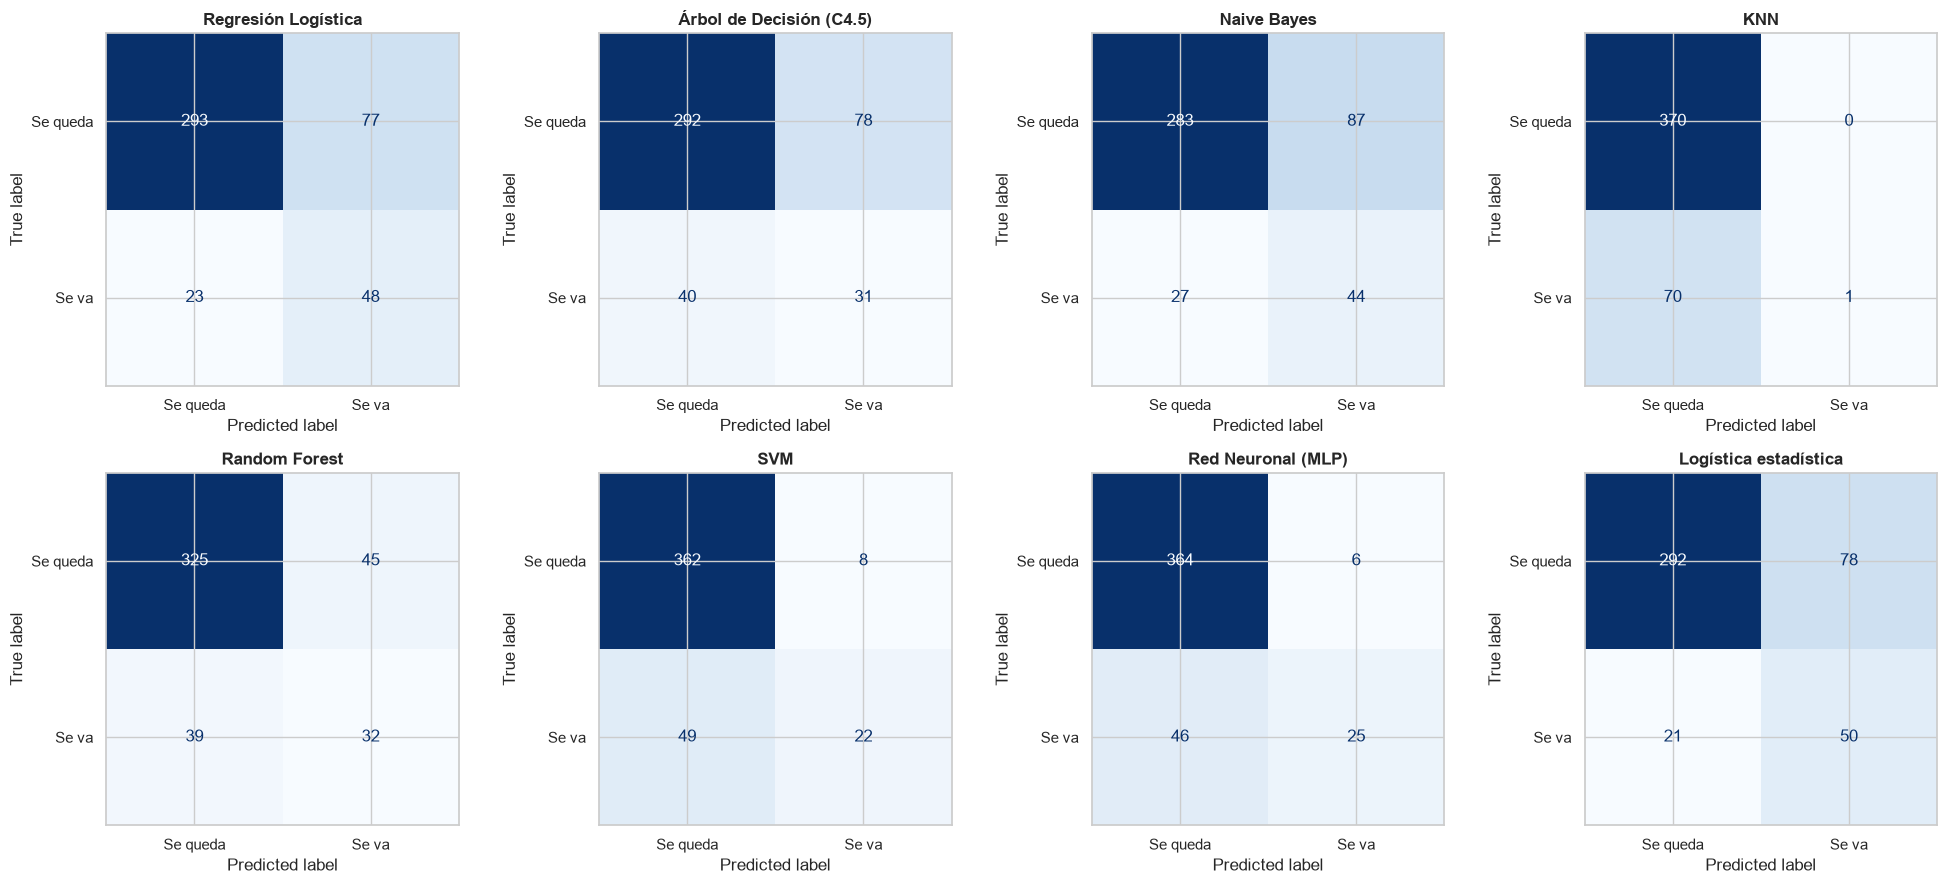

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
todos = dict(probas)
todos["Logística estadística"] = proba_logit
for ax, (n, p) in zip(axes.ravel(), todos.items()):
    u = umbral_logit if n == "Logística estadística" else 0.5
    ConfusionMatrixDisplay(confusion_matrix(y_test, (p >= u).astype(int)),
                           display_labels=["Se queda", "Se va"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(n, fontweight="bold")
plt.tight_layout()
plt.show()

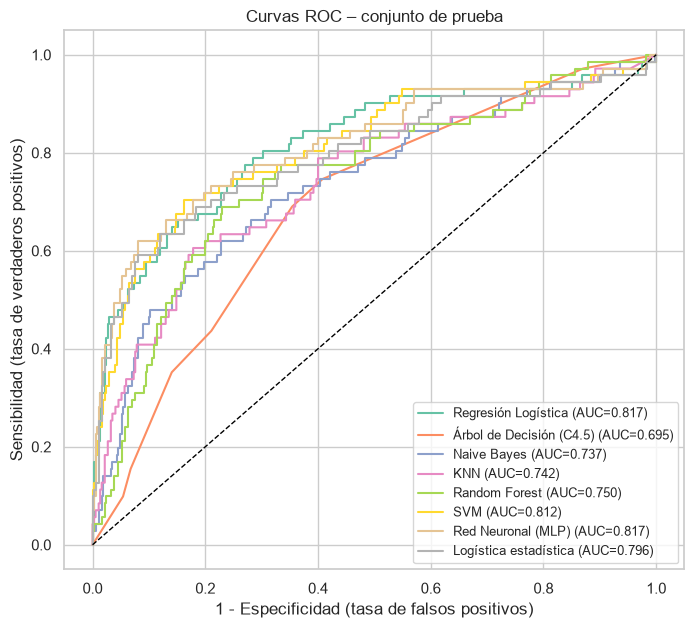

In [21]:
plt.figure(figsize=(8, 7))
for n, p in todos.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{n} (AUC={roc_auc_score(y_test, p):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("1 - Especificidad (tasa de falsos positivos)")
plt.ylabel("Sensibilidad (tasa de verdaderos positivos)")
plt.title("Curvas ROC – conjunto de prueba")
plt.legend(loc="lower right", fontsize=9)
plt.show()

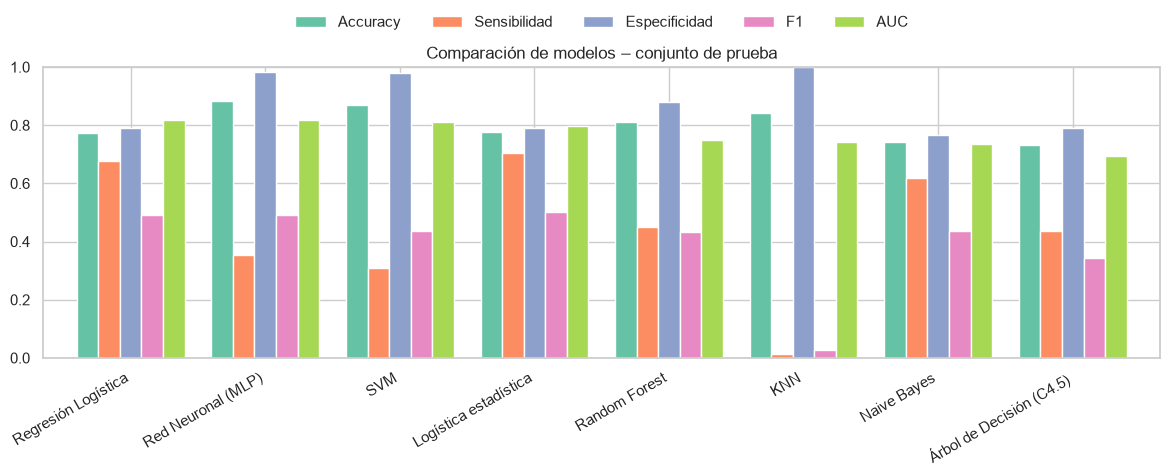

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
resultados[["Accuracy", "Sensibilidad", "Especificidad", "F1", "AUC"]].plot.bar(ax=ax, width=0.8)
ax.set_ylim(0, 1)
ax.set_title("Comparación de modelos – conjunto de prueba")
ax.tick_params(axis="x", rotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.08), ncol=5, frameon=False)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 5.1 Ajuste del umbral de decisión
Con el umbral 0,5, los modelos sin pesos de clase (KNN, Naive Bayes, Red Neuronal) y el SVM (cuyas probabilidades se calibran sin pesos) casi nunca predicen "se va": tienen alta *accuracy* y especificidad pero **baja sensibilidad**, que es justamente lo que le interesa a RRHH. La solución es **mover el umbral**. Para no hacer trampa con el conjunto de prueba, el umbral de cada modelo se elige con **predicciones de validación cruzada sobre el entrenamiento**, maximizando el índice de Youden (sensibilidad + especificidad − 1), y recién después se aplica al conjunto de prueba.

In [23]:
from sklearn.model_selection import cross_val_predict

umbrales, tabla_u = {}, []
for n, m in ajustados.items():
    p_cv = cross_val_predict(m, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    fpr, tpr, thr = roc_curve(y_train, p_cv)
    umbrales[n] = thr[np.argmax(tpr - fpr)]
    tabla_u.append(metricas(n, y_test, probas[n], umbrales[n]) | {"Umbral": umbrales[n]})
tabla_u.append(metricas("Logística estadística", y_test, proba_logit, umbral_logit) | {"Umbral": umbral_logit})

resultados_u = pd.DataFrame(tabla_u).set_index("Modelo").sort_values(["AUC", "F1"], ascending=False)
resultados_u.round(3).to_csv("resultados_modelos_umbral_ajustado.csv", encoding="utf-8-sig")
resultados_u.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0,
                                                         subset=["Accuracy", "Sensibilidad", "Especificidad", "F1", "AUC"])

,Accuracy,Sensibilidad,Especificidad,Precisión,F1,AUC,Umbral
Modelo,,,,,,,
Regresión Logística,0.846,0.577,0.897,0.519,0.547,0.817,0.649
Red Neuronal (MLP),0.841,0.620,0.884,0.506,0.557,0.817,0.242
SVM,0.819,0.648,0.851,0.455,0.535,0.812,0.218
Logística estadística,0.776,0.704,0.789,0.391,0.503,0.796,0.161
Random Forest,0.723,0.704,0.727,0.331,0.450,0.750,0.378
KNN,0.780,0.606,0.814,0.384,0.470,0.742,0.168
Naive Bayes,0.737,0.620,0.759,0.331,0.431,0.737,0.479
Árbol de Decisión (C4.5),0.778,0.352,0.859,0.325,0.338,0.695,0.621


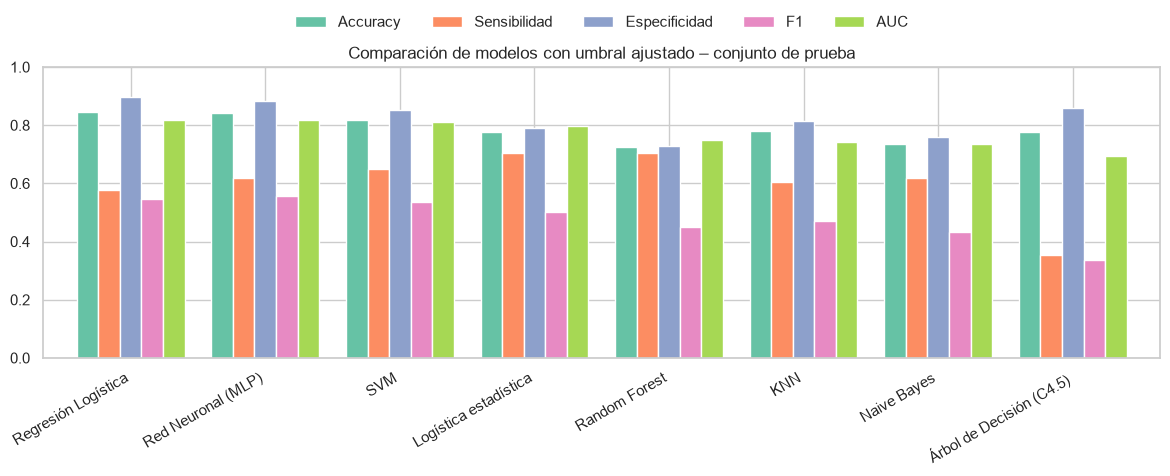

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
resultados_u[["Accuracy", "Sensibilidad", "Especificidad", "F1", "AUC"]].plot.bar(ax=ax, width=0.8)
ax.set_ylim(0, 1)
ax.set_title("Comparación de modelos con umbral ajustado – conjunto de prueba")
ax.tick_params(axis="x", rotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.08), ncol=5, frameon=False)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 5.2 Árbol de decisión: reglas interpretables
Como en el ejemplo de clasificación con C4.5 del material de la unidad, el árbol permite extraer **reglas** comprensibles para RRHH. Se muestra un árbol de profundidad 3 para que sea legible (los valores están normalizados a [0, 1]; p. ej. `OverTime_Yes > 0.5` significa "hace horas extra").

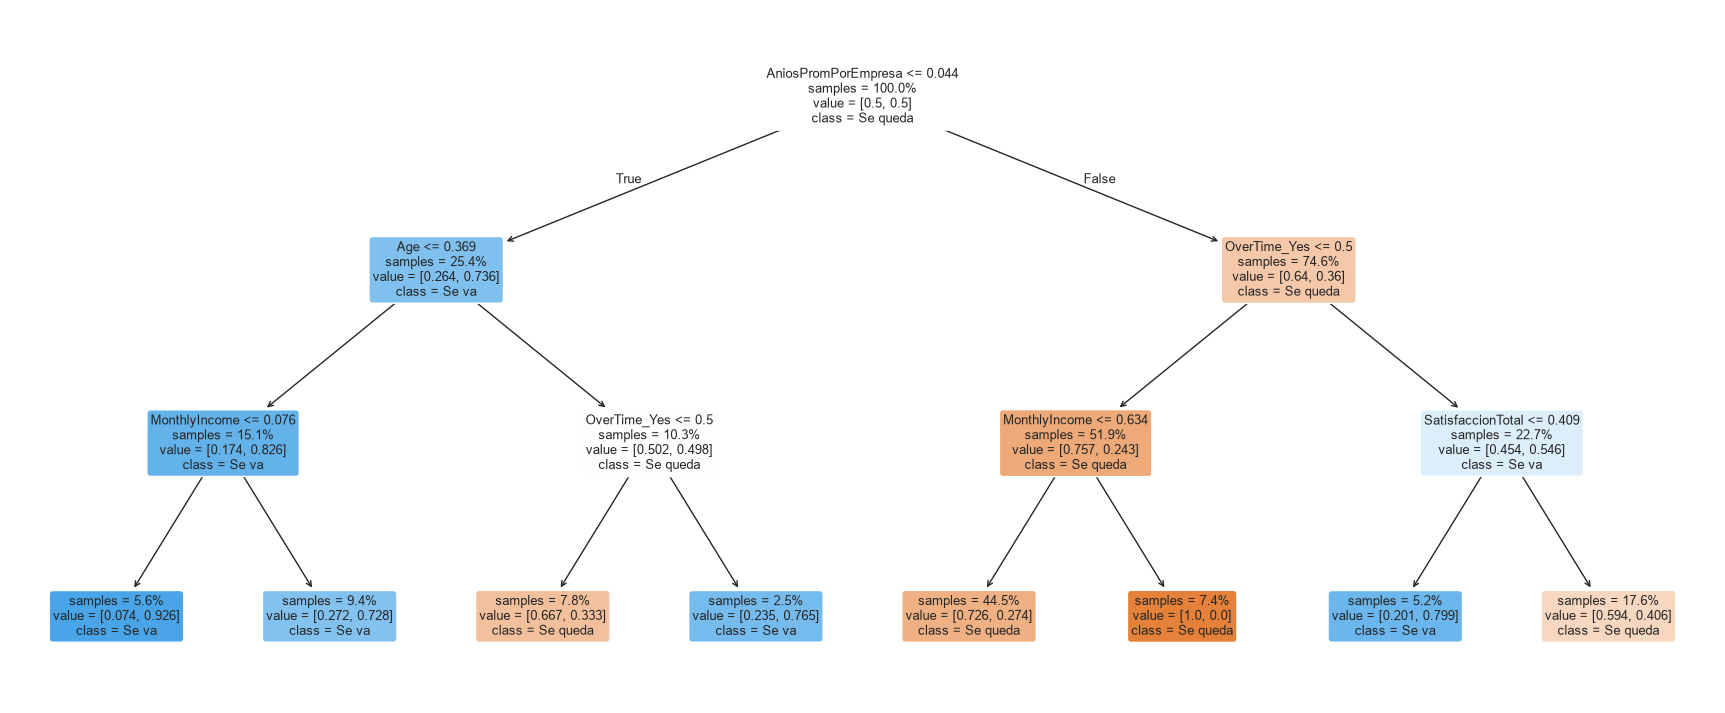

|--- AniosPromPorEmpresa <= 0.04
|   |--- Age <= 0.37
|   |   |--- MonthlyIncome <= 0.08
|   |   |   |--- class: 1
|   |   |--- MonthlyIncome >  0.08
|   |   |   |--- class: 1
|   |--- Age >  0.37
|   |   |--- OverTime_Yes <= 0.50
|   |   |   |--- class: 0
|   |   |--- OverTime_Yes >  0.50
|   |   |   |--- class: 1
|--- AniosPromPorEmpresa >  0.04
|   |--- OverTime_Yes <= 0.50
|   |   |--- MonthlyIncome <= 0.63
|   |   |   |--- class: 0
|   |   |--- MonthlyIncome >  0.63
|   |   |   |--- class: 0
|   |--- OverTime_Yes >  0.50
|   |   |--- SatisfaccionTotal <= 0.41
|   |   |   |--- class: 1
|   |   |--- SatisfaccionTotal >  0.41
|   |   |   |--- class: 0



In [25]:
arbol_simple = Pipeline([("scaler", MinMaxScaler()),
                         ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=3, min_samples_leaf=20,
                                                        class_weight="balanced", random_state=SEED))]).fit(X_train, y_train)
plt.figure(figsize=(22, 9))
plot_tree(arbol_simple["clf"], feature_names=X.columns, class_names=["Se queda", "Se va"],
          filled=True, rounded=True, fontsize=9, impurity=False, proportion=True)
plt.show()
print(export_text(arbol_simple["clf"], feature_names=list(X.columns)))

### 5.3 Importancia de las variables

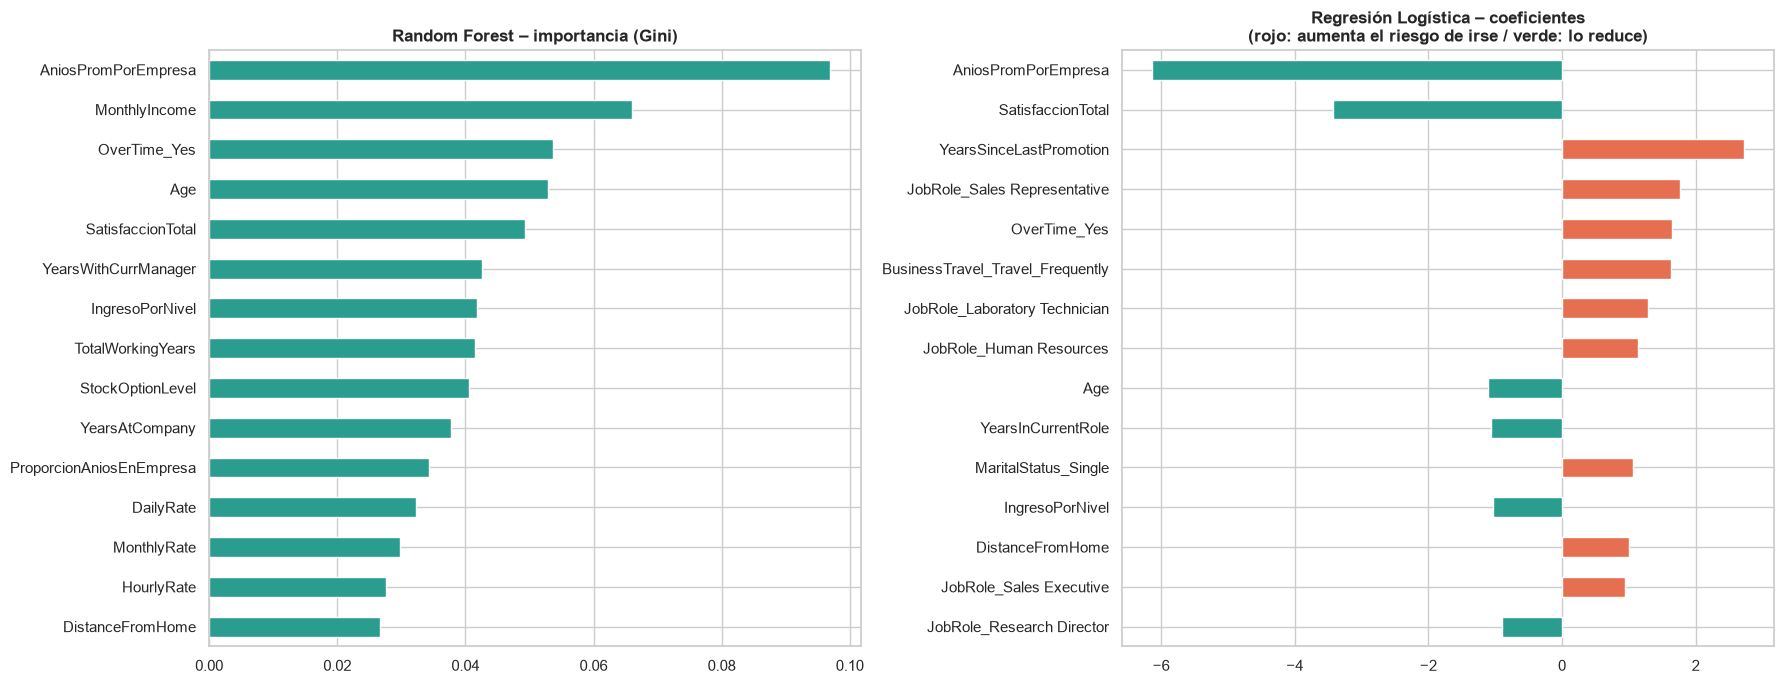

In [26]:
rf = ajustados["Random Forest"]
imp_rf = pd.Series(rf["clf"].feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

lr = ajustados["Regresión Logística"]
coef_lr = pd.Series(lr["clf"].coef_[0], index=X.columns)
top_lr = coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
imp_rf[::-1].plot.barh(ax=axes[0], color="#2a9d8f")
axes[0].set_title("Random Forest – importancia (Gini)", fontweight="bold")
top_lr[::-1].plot.barh(ax=axes[1], color=["#e76f51" if v > 0 else "#2a9d8f" for v in top_lr[::-1]])
axes[1].set_title("Regresión Logística – coeficientes\n(rojo: aumenta el riesgo de irse / verde: lo reduce)", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.4 Aplicación: ranking de riesgo
El uso práctico del modelo es ordenar a los empleados actuales por **probabilidad de irse** para priorizar acciones de retención. Ejemplo con el mejor modelo sobre el conjunto de prueba:

In [27]:
mejor = resultados.drop(index=[i for i in resultados.index if i.startswith("Logística estadística")])["AUC"].idxmax()
print("Mejor modelo por AUC:", mejor)

ranking = df.loc[X_test.index, ["Age", "JobRole", "OverTime", "MaritalStatus", "MonthlyIncome",
                               "YearsAtCompany", "Attrition"]].copy()
ranking["Prob. de irse"] = probas[mejor]
ranking = ranking.sort_values("Prob. de irse", ascending=False)
ranking.head(10)

Mejor modelo por AUC: Regresión Logística


,Age,JobRole,OverTime,MaritalStatus,MonthlyIncome,YearsAtCompany,Attrition,Prob. de irse
911,25,Sales Representative,Yes,Single,1118,1,1,0.989
357,21,Sales Representative,Yes,Single,2174,3,1,0.988
688,19,Sales Representative,Yes,Single,2121,1,1,0.980
656,32,Laboratory Technician,Yes,Single,2795,1,1,0.967
1436,21,Sales Representative,Yes,Single,2380,2,0,0.949
514,33,Research Scientist,Yes,Single,3348,10,1,0.942
915,21,Laboratory Technician,No,Single,2625,2,1,0.939
762,26,Research Scientist,Yes,Married,2042,3,1,0.938
946,40,Sales Executive,Yes,Single,9094,5,1,0.937
1379,27,Human Resources,No,Married,2863,1,1,0.933


In [28]:
# ¿Qué % de los que se van se concentra en el 20 % de mayor riesgo?
top = ranking.head(int(len(ranking) * 0.2))
print(f"El 20 % de empleados con mayor riesgo concentra el {top['Attrition'].sum() / ranking['Attrition'].sum():.0%} "
      f"de las bajas reales (tasa de attrition en ese grupo: {top['Attrition'].mean():.0%} vs {ranking['Attrition'].mean():.0%} general).")

El 20 % de empleados con mayor riesgo concentra el 61% de las bajas reales (tasa de attrition en ese grupo: 49% vs 16% general).


## 6. Conclusiones

**Modelo elegido: Regresión Logística.** Fue el mejor en validación cruzada (AUC 0,83 ± 0,04) y en el conjunto de prueba (AUC 0,82), empatado con la red neuronal y apenas por encima del SVM, pero con la ventaja de ser **interpretable**: cada coeficiente indica cuánto sube o baja el riesgo de irse. Coincide con lo citado por Setiawan et al. (Frye et al., 2018), donde la regresión logística también fue el mejor clasificador de attrition.

| | Paper (Setiawan et al.) | Este trabajo – logística estadística | Este trabajo – logística regularizada (umbral 0,5) |
|---|---|---|---|
| Accuracy | 75 % | 78 % | 77 % |
| Sensibilidad | 73 % | 70 % | 68 % |
| Especificidad | 75 % | 79 % | 79 % |

Los resultados son comparables a los del paper, aunque los datasets no son idénticos (el paper usa la versión de 4.410 empleados con registros de horario).

**Comparación de algoritmos**
- Los modelos **lineales** (logística, SVM lineal) y la **red neuronal** pequeña fueron los mejores (AUC ≈ 0,81–0,82): con pocos datos (1.029 para entrenar, 166 bajas) y relaciones mayormente monótonas, los modelos simples generalizan mejor.
- **Random Forest** (AUC 0,75) mejora mucho al **árbol de decisión** individual (0,70), que es inestable con pocos datos, aunque este último aporta **reglas** muy fáciles de comunicar.
- **KNN** y **Naive Bayes** quedaron atrás (≈ 0,74): KNN sufre con 49 dimensiones y Naive Bayes supone independencia entre variables, que no se cumple (antigüedad, edad e ingreso están muy correlacionadas).
- El **umbral de decisión** es tan importante como el algoritmo: con 0,5 algunos modelos no detectaban casi a nadie. La elección final del umbral es una decisión de negocio: bajar el umbral detecta más bajas a costa de más falsas alarmas (entrevistas de retención "innecesarias", que suelen ser baratas comparadas con reemplazar a un empleado).

**Factores clave de attrition** (consistentes entre EDA, regresión logística, árbol y Random Forest):
1. **Horas extra** – el factor más fuerte (odds ≈ ×7).
2. **Perfil junior / poca trayectoria**: menor edad, pocos años de experiencia por empresa, poco tiempo en la compañía, nivel de puesto 1.
3. **Baja satisfacción** (ambiente, trabajo, relaciones, involucramiento) y **mal balance vida-trabajo**.
4. **Compensación**: ingreso bajo para su nivel y **sin stock options**.
5. **Viajes frecuentes** y **mayor distancia al hogar**.
6. **Rol**: Sales Representative, Laboratory Technician y Human Resources.
7. **Estado civil soltero** y **muchos años sin promoción**.

**Recomendaciones para RRHH**
- Controlar y redistribuir las **horas extra**; revisar cargas de trabajo en los roles críticos.
- **Planes de carrera y promoción** para empleados jóvenes y de nivel 1 (mentoring, objetivos claros de ascenso).
- Revisar **bandas salariales y stock options** en los niveles bajos.
- Políticas de **viajes** y de trabajo remoto/flexible para quienes viven lejos.
- Encuestas periódicas de **clima** y seguimiento de quienes reportan baja satisfacción.
- Usar el **ranking de riesgo** para priorizar entrevistas de retención: el 20 % de mayor riesgo concentra ≈ 60 % de las bajas reales.

**Limitaciones**
- El dataset es **ficticio** y chico (237 bajas); los resultados deben validarse con datos reales.
- Es una **foto estática**: no permite el esquema visto en clase de usar N meses de historia para predecir M meses hacia adelante. Con datos reales conviene construir variables dinámicas (evolución de salario, ausentismo, cambios de jefe, etc.) y reentrenar el modelo periódicamente.
- No distingue attrition **voluntario** de **involuntario**.